<a href="https://colab.research.google.com/github/marcelofschiavo/cd_turnover_pa/blob/main/oop_turnover.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Importa tudo (mesmas bibliotecas da Abordagem 1)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# --- DEFINIÇÃO DA CLASSE ---
class TurnoverAnalysisPipeline:
    """
    Uma Classe para encapsular todo o pipeline de análise de turnover,
    desde a carga dos dados até a avaliação do modelo.
    """

    # 1. O Construtor: Define os atributos iniciais
    def __init__(self, random_state=42):
        print("Iniciando o pipeline...")
        # Atributos de dados (começam vazios)
        self.df_final = None
        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None
        self.feature_names = None

        # Atributo do modelo
        self.model = None
        self.random_state = random_state # Para reprodutibilidade

        # Configurações de visualização
        sns.set_style('whitegrid')
        plt.rcParams['figure.figsize'] = (10, 6)

    # 2. Métodos (as funções, agora dentro da classe)
    # Note que o primeiro argumento é sempre 'self'

    def load_and_merge_data(self):
        """MÉTODO para carregar e juntar os dados."""
        print("ETAPA 1: Carregando e juntando dados...")

        # --- CORREÇÃO: DICIONÁRIOS COMPLETOS COLADOS AQUI ---

        # Dados para a Tabela 1: funcionarios
        data_funcionarios = {
            'id_funcionario': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
                               113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125],
            'nome': ['Ana', 'Bruno', 'Carla', 'Daniel', 'Elisa', 'Fabio', 'Gabi', 'Hugo', 'Ines', 'Joao', 'Leo', 'Maria',
                     'Nina', 'Otavio', 'Paula', 'Renan', 'Sara', 'Tiago', 'Uva', 'Vera', 'Xuxa', 'Yuri', 'Zeca', 'Alice', 'Beto'],
            'idade': [28, 35, 24, 40, 33, 29, 45, 31, 27, 38, 26, 41, 29, 34, 42, 36, 23, 30, 39, 44, 32, 28, 48, 51, 33],
            'departamento': ['Vendas', 'TI', 'RH', 'TI', 'Vendas', 'TI', 'RH', 'Vendas', 'TI', 'RH', 'Vendas', 'TI',
                             'Marketing', 'Marketing', 'Vendas', 'TI', 'RH', 'Marketing', 'TI', 'Vendas', 'RH', 'Vendas', 'TI', 'Marketing', 'TI'],
            'salario': [5000, 8000, 4500, 9500, 6000, 7200, 5100, 5800, 9000, 4900, 4800, 10500,
                        6500, 6800, 7100, 8200, 4700, 6600, 9200, 7300, 5000, 5200, 11000, 7000, 8800],
            'tempo_de_empresa_anos': [3, 5, 1, 8, 6, 3, 10, 4, 7, 5, 2, 9, 2, 4, 8, 6, 1, 3, 7, 10, 3, 2, 12, 9, 5],
            'pediu_demissao': [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0] # 1=Sim, 0=Não
        }
        # Dados para a Tabela 2: avaliacoes_2024
        data_avaliacoes = {
            'id_avaliacao': list(range(1, 26)),
            'id_funcionario': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
                               113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125],
            'nota_desempenho': [3, 5, 2, 4, 5, 3, 3, 4, 5, 3, 2, 5, 3, 4, 4, 5, 2, 3, 4, 4, 2, 3, 5, 4, 4], # Escala 1-5
            'satisfacao_trabalho': [2, 5, 1, 4, 5, 4, 3, 4, 5, 2, 2, 4, 2, 3, 5, 4, 1, 3, 5, 4, 1, 2, 5, 3, 4], # Escala 1-5
            'num_projetos': [5, 3, 6, 4, 3, 4, 5, 4, 3, 5, 6, 4, 5, 4, 3, 3, 6, 5, 4, 3, 5, 6, 3, 4, 4]
        }

        # --- FIM DA CORREÇÃO ---

        df_funcionarios = pd.DataFrame(data_funcionarios)
        df_avaliacoes = pd.DataFrame(data_avaliacoes)

        df_merged = pd.merge(df_funcionarios, df_avaliacoes, on='id_funcionario', how='inner')

        # ATENÇÃO: Agora salvamos o resultado em 'self.df_final'
        self.df_final = df_merged.drop(columns=['id_funcionario', 'nome'])
        print("Dados carregados e salvos em 'self.df_final'.")

    def run_exploratory_analysis(self):
        """MÉTODO para rodar a EDA."""
        if self.df_final is None:
            print("Erro: Os dados não foram carregados. Rode .load_and_merge_data() primeiro.")
            return

        print("\nETAPA 2: Análise Exploratória (EDA)...")
        print(self.df_final.groupby('pediu_demissao').mean(numeric_only=True).T)

        # Gráfico 1
        sns.countplot(x='satisfacao_trabalho', hue='pediu_demissao', data=self.df_final, palette='pastel')
        plt.title('Impacto da Satisfação no Trabalho no Turnover')
        plt.show()

        # Gráfico 2
        sns.boxplot(x='pediu_demissao', y='salario', data=self.df_final, palette='pastel', hue='pediu_demissao', legend=False)
        plt.title('Distribuição Salarial de quem Fica vs. Sai')
        plt.xticks([0, 1], ['Ficou (0)', 'Saiu (1)'])
        plt.show()

        # Gráfico 3
        sns.histplot(data=self.df_final, x='tempo_de_empresa_anos', hue='pediu_demissao',
                     multiple='dodge', kde=True, bins=12)
        plt.title('Tempo de Empresa vs. Turnover')
        plt.show()


    def run_statistical_tests(self):
        """MÉTODO para rodar os testes estatísticos."""
        if self.df_final is None:
            print("Erro: Os dados não foram carregados.")
            return

        print("\nETAPA 3: Testes Estatísticos...")
        # Teste-T para Salário
        salario_saiu = self.df_final[self.df_final['pediu_demissao'] == 1]['salario']
        salario_ficou = self.df_final[self.df_final['pediu_demissao'] == 0]['salario']
        stat, pvalue_salario = stats.ttest_ind(salario_saiu, salario_ficou, equal_var=False)
        print(f"P-value do Teste-T (Salário): {pvalue_salario:.5f}")

        # Teste-T para Satisfação
        satisfacao_saiu = self.df_final[self.df_final['pediu_demissao'] == 1]['satisfacao_trabalho']
        satisfacao_ficou = self.df_final[self.df_final['pediu_demissao'] == 0]['satisfacao_trabalho']
        stat, pvalue_satisfacao = stats.ttest_ind(satisfacao_saiu, satisfacao_ficou, equal_var=False)
        print(f"P-value do Teste-T (Satisfação): {pvalue_satisfacao:.5f}")

    def preprocess_for_ml(self):
        """MÉTODO para pré-processar e dividir os dados."""
        if self.df_final is None:
            print("Erro: Os dados não foram carregados.")
            return

        print("\nETAPA 4: Pré-processamento para ML...")
        df_modelo = pd.get_dummies(self.df_final, columns=['departamento'], drop_first=True)

        X = df_modelo.drop(columns=['pediu_demissao'])
        y = df_modelo['pediu_demissao']

        # Salva os nomes das features em 'self'
        self.feature_names = X.columns

        # Salva os dados divididos em 'self'
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y,
            test_size=0.3,
            random_state=self.random_state,
            stratify=y
        )
        print(f"Dados divididos e salvos em 'self.X_train', 'self.X_test', etc.")

    def train_and_evaluate_model(self):
        """MÉTODO para treinar e avaliar o modelo."""
        if self.X_train is None:
            print("Erro: Os dados não foram pré-processados. Rode .preprocess_for_ml() primeiro.")
            return

        print("\nETAPA 5: Treinamento e Avaliação do Modelo...")

        # Instancia, treina e salva o modelo em 'self.model'
        self.model = RandomForestClassifier(
            n_estimators=100,
            random_state=self.random_state,
            class_weight='balanced'
        )
        self.model.fit(self.X_train, self.y_train)

        y_pred = self.model.predict(self.X_test)

        print(f"Acurácia: {accuracy_score(self.y_test, y_pred):.2f}")
        print("\nRelatório de Classificação:")
        print(classification_report(self.y_test, y_pred))

        # Interpretabilidade
        print("\n--- Fatores Preditivos (Feature Importance) ---")
        importances = self.model.feature_importances_
        feature_importance_df = pd.Series(importances, index=self.feature_names).sort_values(ascending=False)
        print(feature_importance_df)

        sns.barplot(x=feature_importance_df.values, y=feature_importance_df.index, palette='viridis', hue=feature_importance_df.index, legend=False)
        plt.title('Importância de Cada Fator na Previsão de Turnover', fontsize=16)
        plt.show()

    # 3. Um Método "Controlador" para rodar tudo em ordem
    def run_full_pipeline(self):
        """
        Executa todas as etapas do pipeline em sequência.
        """
        self.load_and_merge_data()
        self.run_exploratory_analysis()
        self.run_statistical_tests()
        self.preprocess_for_ml()
        self.train_and_evaluate_model()
        print("\n--- Pipeline concluído. 'pipeline.model' está treinado. ---")

Iniciando o pipeline...
ETAPA 1: Carregando e juntando dados...
Dados carregados e salvos em 'self.df_final'.

ETAPA 2: Análise Exploratória (EDA)...
pediu_demissao                   0            1
idade                    37.555556    27.142857
salario                7666.666667  5100.000000
tempo_de_empresa_anos     6.722222     2.000000
id_avaliacao             13.166667    12.571429
nota_desempenho           4.111111     2.428571
satisfacao_trabalho       4.000000     1.571429
num_projetos              3.777778     5.571429


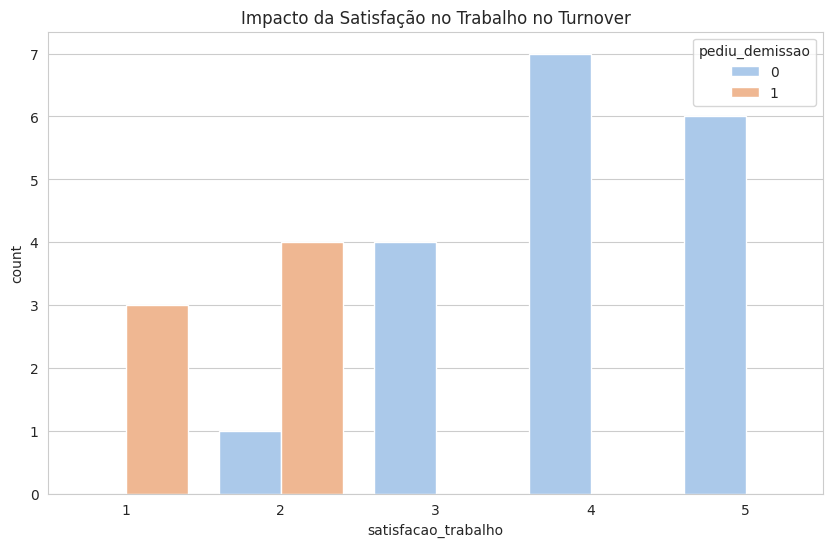

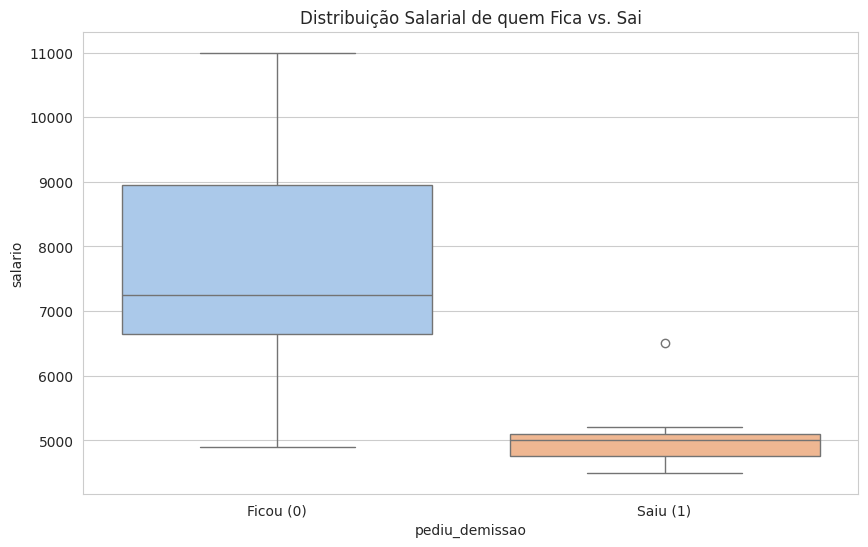

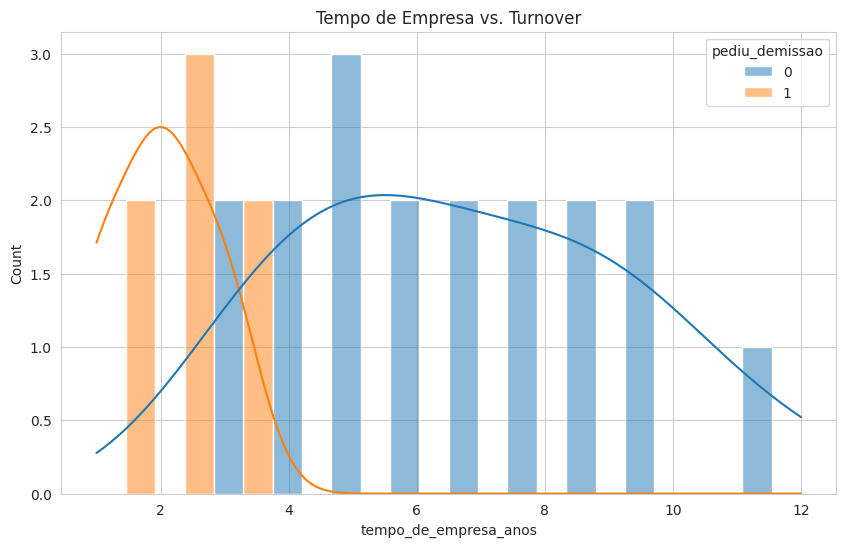


ETAPA 3: Testes Estatísticos...
P-value do Teste-T (Salário): 0.00002
P-value do Teste-T (Satisfação): 0.00000

ETAPA 4: Pré-processamento para ML...
Dados divididos e salvos em 'self.X_train', 'self.X_test', etc.

ETAPA 5: Treinamento e Avaliação do Modelo...
Acurácia: 0.62

Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.40      1.00      0.57         2

    accuracy                           0.62         8
   macro avg       0.70      0.75      0.62         8
weighted avg       0.85      0.62      0.64         8


--- Fatores Preditivos (Feature Importance) ---
num_projetos             0.248221
satisfacao_trabalho      0.226808
tempo_de_empresa_anos    0.134381
salario                  0.127563
nota_desempenho          0.126202
idade                    0.108392
departamento_TI          0.011281
departamento_RH          0.010000
id_avaliacao             0.005975
departamento

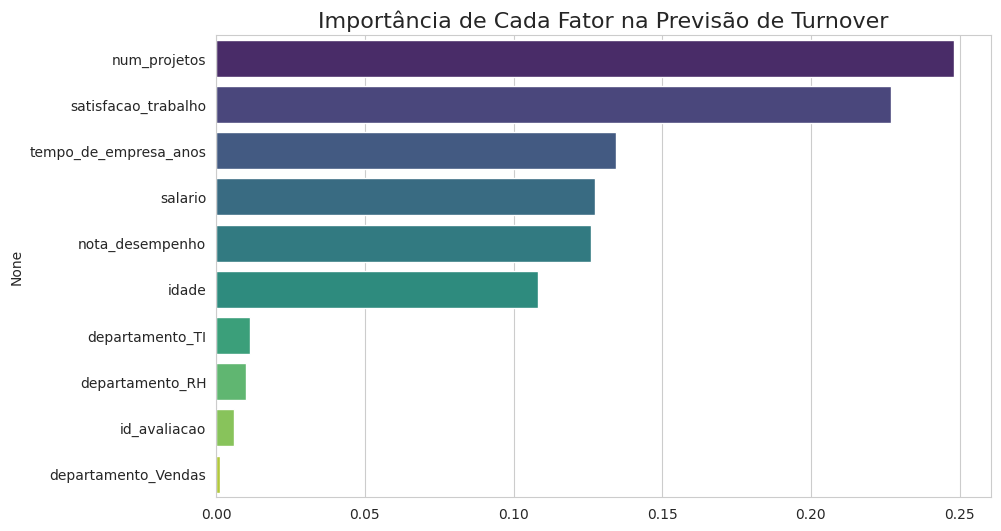


--- Pipeline concluído. 'pipeline.model' está treinado. ---


In [4]:
# --- EXECUTANDO O PIPELINE OOP ---

# 1. Instanciar a Classe (Criar o objeto)
# 'pipeline_@empresa' é agora um objeto que contém todo o nosso projeto.
pipeline_empresa = TurnoverAnalysisPipeline()

# 2. Executar o pipeline inteiro com um único comando
pipeline_empresa.run_full_pipeline()

# 3. (Opcional) Acessar o modelo treinado depois
# print(pipeline_empresa.model)